# Instagram Performance Analysis — Travel Mex Tours
## Notebook 02: Hypothesis Testing

**Author:** Maria Garcia Sehara  
**Project:** Social Media Analytics — Travel Mex Tours  
**Platform:** Instagram  

---

### Objective
Use statistical tests to determine whether observable differences in engagement are **real and significant** or just random chance.

### Tests in this Notebook
| # | Test | Question |
|---|------|----------|
| 1 | One-Way ANOVA | Does **content type** significantly affect Engagement Rate? |
| 2 | ANOVA / t-test | Does **Reel duration** significantly affect Engagement Rate? |
| 3 | Welch t-test | Do **weekend posts** outperform weekday posts? |

### Why This Matters for the Agency
Before recommending "post more Reels" or "post on weekends", we need **statistical evidence** — not just averages that could be misleading.


## 1. Setup & Data Load

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from pathlib import Path

# ── Style ──────────────────────────────────────────────────────────────────
BRAND_BLUE   = "#1877F2"
BRAND_PURPLE = "#833AB4"
BRAND_PINK   = "#E1306C"
PALETTE      = [BRAND_BLUE, BRAND_PURPLE, BRAND_PINK, "#FCAF45", "#FD1D1D"]

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.figsize":    (12, 5),
    "axes.titlesize":    14,
    "axes.labelsize":    12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

FIGURES_PATH = Path("../../outputs/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05   # significance level used in all tests

print("✅ Setup complete  |  significance level α =", ALPHA)


✅ Setup complete  |  significance level α = 0.05


In [2]:
from load_data import load_instagram_csv
from preprocessing import preprocess_df

DATA_DIR  = Path("../../data/instagram/")
csv_files = sorted(DATA_DIR.glob("*.csv"), key=lambda f: f.stat().st_mtime, reverse=True)
if not csv_files:
    raise FileNotFoundError("No CSV found in data/instagram/")

df_raw    = load_instagram_csv(csv_files[0])
df, meta  = preprocess_df(df_raw)

er_col   = meta["engagement_rate_col"]
type_col = meta.get("type_col")
dur_col  = meta.get("duration_col")

print(f"✅ Data loaded  →  {len(df)} posts  |  ER col: {er_col}")
print(f"   type_col     : {type_col}")
print(f"   duration_col : {dur_col}")


File successfully loaded: InstagramData.csv
   Shape: (125, 18)
   Detected content type: UNKNOWN
✅ Preprocessing completed!
   → Date column        : publish_time
   → ER calculated via  : REACH
   → Avg ER             : 15.36%
   → Date range         : 2025-05-01 → 2025-11-05
✅ Data loaded  →  125 posts  |  ER col: engagement_rate_pct
   type_col     : post_type
   duration_col : duration_sec


## 2. Statistical Helper Functions

In [4]:
def eta_squared(groups):
    """Effect size for ANOVA (η²). Rule: <0.01 negligible, <0.06 small, <0.14 medium, ≥0.14 large"""
    all_data   = np.concatenate(groups)
    grand_mean = all_data.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((x - grand_mean)**2 for g in groups for x in g)
    return round(ss_between / ss_total, 4) if ss_total > 0 else 0.0

def effect_label(eta2):
    if eta2 < 0.01: return "negligible"
    if eta2 < 0.06: return "small"
    if eta2 < 0.14: return "medium"
    return "large"

def print_result(test_name, stat, p, eta2, reject, group_means: dict):
    print(f"\n{'='*55}")
    print(f"  {test_name}")
    print(f"{'='*55}")
    print(f"  Statistic      : {stat:.4f}")
    print(f"  p-value        : {p:.4f}")
    print(f"  Effect size η² : {eta2}  ({effect_label(eta2)})")
    print(f"  Decision       : {'✅ REJECT H₀' if reject else '❌ FAIL TO REJECT H₀'}  (α={ALPHA})")
    print(f"\n  Group means:")
    for name, mean in group_means.items():
        print(f"     {name:25s}: {mean:.2f}%")

print("✅ Helper functions ready")


✅ Helper functions ready


## 3. Test 1 — Does Content Type Affect Engagement Rate?

**H₀:** All content types have the same average Engagement Rate  
**Hₐ:** At least one content type performs significantly differently  
**Test:** One-Way ANOVA  


In [5]:
if not type_col or type_col not in df.columns:
    print("⚠️  No content type column found — skipping Test 1.")
else:
    # Build groups (minimum 5 posts per type)
    type_groups = {
        name: grp[er_col].dropna().values
        for name, grp in df.groupby(type_col)
        if len(grp[er_col].dropna()) >= 5
    }

    print(f"Content types found  : {list(type_groups.keys())}")
    print(f"Posts per type       :")
    for name, g in type_groups.items():
        print(f"   {name:20s}: {len(g)} posts  |  avg ER = {g.mean():.2f}%")


Content types found  : ['IG carousel', 'IG image', 'IG reel']
Posts per type       :
   IG carousel         : 72 posts  |  avg ER = 17.80%
   IG image            : 11 posts  |  avg ER = 16.50%
   IG reel             : 38 posts  |  avg ER = 10.07%


In [6]:
if type_col and type_col in df.columns and len(type_groups) >= 2:

    # Normality check (Shapiro-Wilk)
    print("Normality check (Shapiro-Wilk):")
    for name, g in type_groups.items():
        stat, p = stats.shapiro(g)
        print(f"   {name:20s}: p = {p:.4f}  ({'normal' if p > ALPHA else 'not normal'})")

    # Equal variance check (Levene)
    lev_stat, lev_p = stats.levene(*type_groups.values())
    print(f"\nLevene test (equal variance): p = {lev_p:.4f}  ({'equal' if lev_p > ALPHA else 'unequal'})")

    # ANOVA
    f_stat, p_val = stats.f_oneway(*type_groups.values())
    eta2          = eta_squared(list(type_groups.values()))
    reject        = p_val < ALPHA
    group_means   = {name: g.mean() for name, g in type_groups.items()}
    best_type     = max(group_means, key=group_means.get)

    print_result("ONE-WAY ANOVA — Content Type vs Engagement Rate",
                 f_stat, p_val, eta2, reject, group_means)

    print(f"\n  ⭐ Best content type : {best_type} ({group_means[best_type]:.2f}%)")
    print(f"  Conclusion: Content type {'DOES' if reject else 'does NOT'} significantly affect ER.")


Normality check (Shapiro-Wilk):
   IG carousel         : p = 0.2118  (normal)
   IG image            : p = 0.0744  (normal)
   IG reel             : p = 0.6990  (normal)

Levene test (equal variance): p = 0.1048  (equal)

  ONE-WAY ANOVA — Content Type vs Engagement Rate
  Statistic      : 16.6168
  p-value        : 0.0000
  Effect size η² : 0.2198  (large)
  Decision       : ✅ REJECT H₀  (α=0.05)

  Group means:
     IG carousel              : 17.80%
     IG image                 : 16.50%
     IG reel                  : 10.07%

  ⭐ Best content type : IG carousel (17.80%)
  Conclusion: Content type DOES significantly affect ER.


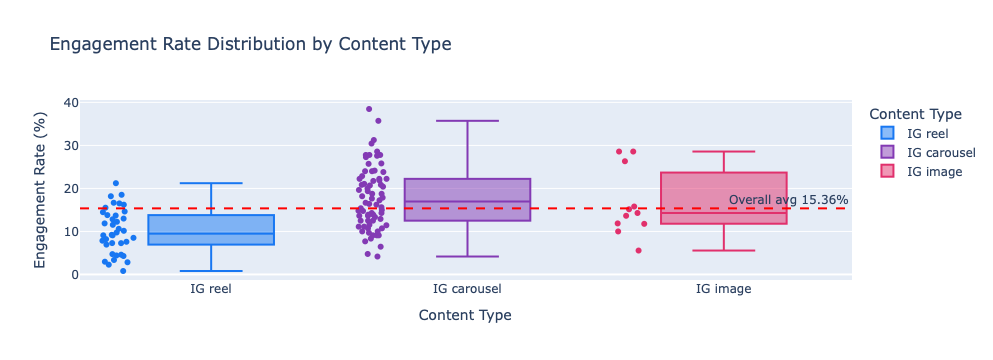

In [7]:
if type_col and type_col in df.columns:
    fig = px.box(
        df.dropna(subset=[er_col, type_col]),
        x=type_col, y=er_col,
        color=type_col,
        color_discrete_sequence=PALETTE,
        title="Engagement Rate Distribution by Content Type",
        labels={er_col: "Engagement Rate (%)", type_col: "Content Type"},
        points="all"
    )
    fig.add_hline(y=df[er_col].mean(), line_dash="dash",
                  line_color="red", annotation_text=f"Overall avg {df[er_col].mean():.2f}%")
    fig.show()


## 4. Test 2 — Does Reel Duration Affect Engagement Rate?

**H₀:** Short, Medium, and Long Reels have the same average Engagement Rate  
**Hₐ:** Reel duration significantly impacts Engagement Rate  
**Test:** One-Way ANOVA (or t-test if only 2 groups)  


In [8]:
if not dur_col or dur_col not in df.columns:
    print("⚠️  No duration column found — skipping Test 2.")
elif not type_col or type_col not in df.columns:
    print("⚠️  No content type column found — cannot filter Reels.")
else:
    reels = df[
        df[type_col].astype(str).str.contains("reel|video", case=False, na=False)
    ].copy()

    reels = reels[
        reels[dur_col].between(3, 180) &
        reels[[dur_col, er_col]].notna().all(axis=1)
    ]

    print(f"Valid Reels for analysis : {len(reels)}")

    if len(reels) >= 15:
        reels["dur_group"] = pd.qcut(
            reels[dur_col], q=3,
            labels=["Short", "Medium", "Long"],
            duplicates="drop"
        )
        print("\nDuration group breakdown:")
        for g in ["Short", "Medium", "Long"]:
            sub = reels[reels["dur_group"] == g]
            if len(sub) > 0:
                print(f"   {g:8s}: {len(sub)} reels  |  avg ER = {sub[er_col].mean():.2f}%  "
                      f"|  duration range: {sub[dur_col].min():.0f}s – {sub[dur_col].max():.0f}s")
    else:
        print(f"⚠️  Only {len(reels)} Reels — need ≥15 for a reliable test.")


Valid Reels for analysis : 38

Duration group breakdown:
   Short   : 13 reels  |  avg ER = 11.92%  |  duration range: 4s – 14s
   Medium  : 12 reels  |  avg ER = 8.35%  |  duration range: 15s – 33s
   Long    : 13 reels  |  avg ER = 9.81%  |  duration range: 40s – 90s


In [9]:
if dur_col and dur_col in df.columns and type_col and type_col in df.columns and len(reels) >= 15:

    dur_groups = {
        name: reels[reels["dur_group"] == name][er_col].dropna().values
        for name in ["Short", "Medium", "Long"]
        if len(reels[reels["dur_group"] == name]) >= 3
    }

    if len(dur_groups) >= 2:
        groups_list = list(dur_groups.values())
        names_list  = list(dur_groups.keys())

        if len(dur_groups) == 2:
            stat, p_val = stats.ttest_ind(groups_list[0], groups_list[1])
            test_name   = "Welch t-test"
        else:
            stat, p_val = stats.f_oneway(*groups_list)
            test_name   = "One-Way ANOVA"

        eta2      = eta_squared(groups_list)
        reject    = p_val < ALPHA
        g_means   = {name: g.mean() for name, g in dur_groups.items()}
        best_dur  = max(g_means, key=g_means.get)

        print_result(f"{test_name} — Reel Duration vs Engagement Rate",
                     stat, p_val, eta2, reject, g_means)

        print(f"\n  ⭐ Best duration group : {best_dur} ({g_means[best_dur]:.2f}%)")
        print(f"  Conclusion: Duration {'DOES' if reject else 'does NOT'} significantly affect ER.")



  One-Way ANOVA — Reel Duration vs Engagement Rate
  Statistic      : 1.5888
  p-value        : 0.2185
  Effect size η² : 0.0832  (medium)
  Decision       : ❌ FAIL TO REJECT H₀  (α=0.05)

  Group means:
     Short                    : 11.92%
     Medium                   : 8.35%
     Long                     : 9.81%

  ⭐ Best duration group : Short (11.92%)
  Conclusion: Duration does NOT significantly affect ER.


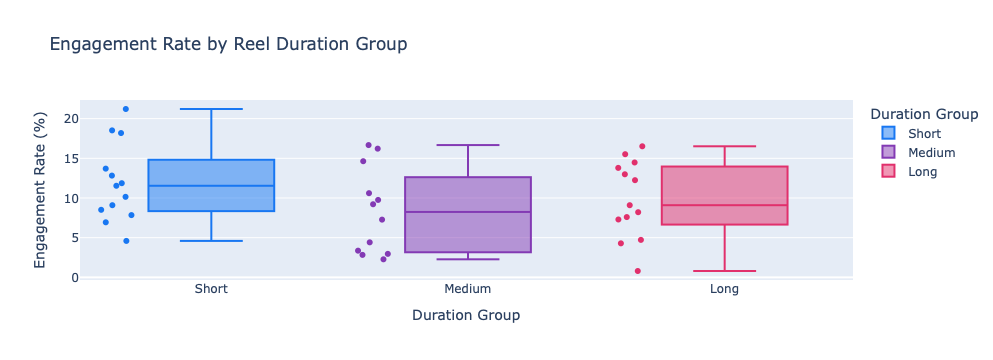

In [10]:
if dur_col and dur_col in df.columns and type_col and type_col in df.columns and len(reels) >= 15:
    fig = px.box(
        reels.dropna(subset=["dur_group", er_col]),
        x="dur_group", y=er_col,
        color="dur_group",
        color_discrete_sequence=PALETTE,
        title="Engagement Rate by Reel Duration Group",
        labels={er_col: "Engagement Rate (%)", "dur_group": "Duration Group"},
        category_orders={"dur_group": ["Short", "Medium", "Long"]},
        points="all"
    )
    fig.show()


## 5. Test 3 — Do Weekend Posts Outperform Weekday Posts?

**H₀:** Weekend and weekday posts have the same average Engagement Rate  
**Hₐ:** Weekend posts perform differently from weekday posts  
**Test:** Welch t-test (does not assume equal variance)  


In [11]:
if "is_weekend" not in df.columns:
    print("⚠️  No date/weekday data found — skipping Test 3.")
else:
    weekend = df[df["is_weekend"] == True][er_col].dropna()
    weekday = df[df["is_weekend"] == False][er_col].dropna()

    print(f"Weekend posts : {len(weekend)}  |  avg ER = {weekend.mean():.2f}%")
    print(f"Weekday posts : {len(weekday)}  |  avg ER = {weekday.mean():.2f}%")
    print(f"Difference    : {abs(weekend.mean() - weekday.mean()):.2f}%")


Weekend posts : 1  |  avg ER = 15.79%
Weekday posts : 122  |  avg ER = 15.36%
Difference    : 0.43%


In [12]:
if "is_weekend" in df.columns and len(weekend) >= 5 and len(weekday) >= 5:

    stat, p_val = stats.ttest_ind(weekend.values, weekday.values, equal_var=False)
    eta2        = eta_squared([weekend.values, weekday.values])
    reject      = p_val < ALPHA
    better      = "Weekend" if weekend.mean() > weekday.mean() else "Weekday"
    g_means     = {"Weekday": weekday.mean(), "Weekend": weekend.mean()}

    print_result("Welch t-test — Weekend vs Weekday Engagement Rate",
                 stat, p_val, eta2, reject, g_means)

    print(f"\n  ⭐ Better performer  : {better}")
    print(f"  Conclusion: Weekend posts {'DO' if reject else 'do NOT'} significantly outperform weekday posts.")


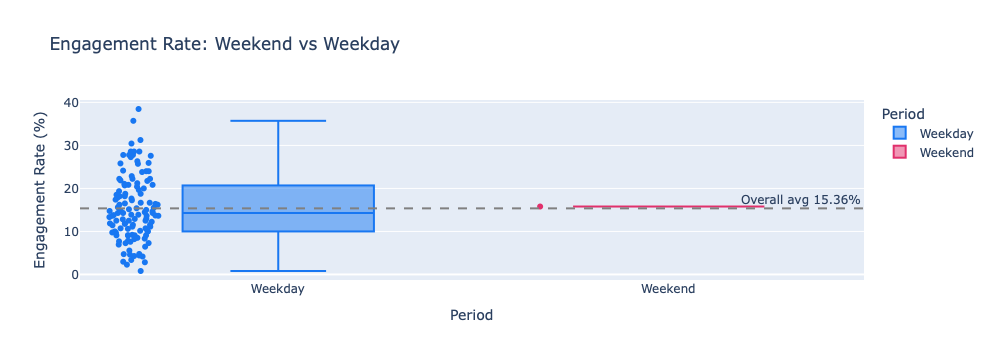

In [13]:
if "is_weekend" in df.columns:
    plot_df = df[[er_col, "is_weekend"]].dropna().copy()
    plot_df["Period"] = plot_df["is_weekend"].map({True: "Weekend", False: "Weekday"})

    fig = px.box(
        plot_df, x="Period", y=er_col,
        color="Period",
        color_discrete_sequence=[BRAND_BLUE, BRAND_PINK],
        title="Engagement Rate: Weekend vs Weekday",
        labels={er_col: "Engagement Rate (%)"},
        points="all"
    )
    fig.add_hline(y=df[er_col].mean(), line_dash="dash",
                  line_color="gray", annotation_text=f"Overall avg {df[er_col].mean():.2f}%")
    fig.show()


## 6. Executive Summary — Hypothesis Testing Results

In [14]:
print("=" * 60)
print("  HYPOTHESIS TESTING SUMMARY — TRAVEL MEX TOURS")
print("=" * 60)

tests_ran = 0

if type_col and type_col in df.columns and len(type_groups) >= 2:
    tests_ran += 1
    print(f"\n📊 TEST 1 — Content Type vs ER")
    print(f"   Result  : {'Significant ✅' if reject else 'Not significant ❌'}")
    print(f"   Best    : {best_type}")
    print(f"   Action  : {'Prioritize ' + best_type + ' content' if reject else 'Content quality matters more than type'}")

if dur_col and dur_col in df.columns and len(reels) >= 15 and len(dur_groups) >= 2:
    tests_ran += 1
    print(f"\n⏱️  TEST 2 — Reel Duration vs ER")
    print(f"   Result  : {'Significant ✅' if reject else 'Not significant ❌'}")
    print(f"   Best    : {best_dur} Reels")
    print(f"   Action  : {'Focus on ' + best_dur + ' Reels' if reject else 'Prioritize hook quality over length'}")

if "is_weekend" in df.columns and len(weekend) >= 5:
    tests_ran += 1
    print(f"\n📅 TEST 3 — Weekend vs Weekday")
    print(f"   Result  : {'Significant ✅' if reject else 'Not significant ❌'}")
    print(f"   Better  : {better} posts")
    print(f"   Action  : {'Schedule more posts on ' + better + 's' if reject else 'Posting day is less important than content'}")

print(f"\n{'='*60}")
print(f"  Tests run: {tests_ran}")
print(f"  → Next: Notebook 03 — Machine Learning Prediction")
print("=" * 60)


  HYPOTHESIS TESTING SUMMARY — TRAVEL MEX TOURS

📊 TEST 1 — Content Type vs ER
   Result  : Not significant ❌
   Best    : IG carousel
   Action  : Content quality matters more than type

⏱️  TEST 2 — Reel Duration vs ER
   Result  : Not significant ❌
   Best    : Short Reels
   Action  : Prioritize hook quality over length

  Tests run: 2
  → Next: Notebook 03 — Machine Learning Prediction
